In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from src.utilities import green2d
from src.quadrature.filon import composite_filon
from src.quadrature.levin import composite_levin
from scipy.special import legendre, roots_legendre
from src.reflectivity_kx_omega import reflectivity
from src.utilities import find_critical_angles

In [3]:
def reflectivity2(theta):
    return np.cos(3*theta) / (1.0 + theta**2) #1.

def reflectivity2_vec(theta):
    return np.cos(3*theta) / (1.0 + theta**2) #np.ones_like(theta)

def g(theta, z_abs, x):
    """Phase function g(theta) = |z|*cos(theta) + x*sin(theta)"""
    return z_abs * np.cos(theta) + x * np.sin(theta)

def int_prop(theta, k0, z_abs, x, R_func):
    """integrand: R(theta) * exp(i * k0 * g(theta))"""
    R_val = R_func(theta)
    return R_val * np.exp(1j * k0 * g(theta, z_abs, x))

def gauss_legendre_quad(A, B, N_points, k0, z_abs, x, R_func, integrand=int_prop):
    t, w = roots_legendre(N_points)
    scale_factor = (B - A) / 2.0
    theta_i = scale_factor * t + (B + A) / 2.0
    F_i = integrand(theta_i, k0, z_abs, x, R_func)
    integral_approx = scale_factor * np.sum(w * F_i)
    return integral_approx

Layer 1 -> Layer 2: 31.15° (v=2900.0 m/s)
Minimum critical angle: 31.15°


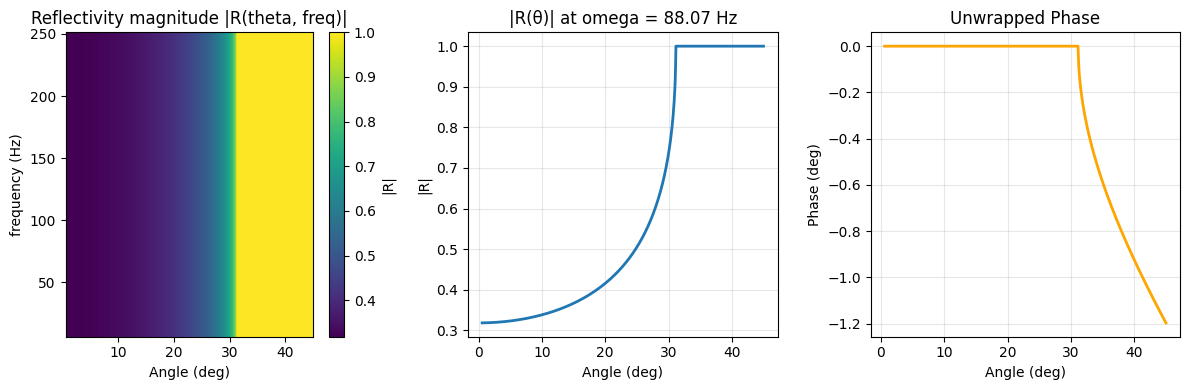

In [4]:
'''layers = [
        (100.0, 1505.0, 2000.0), # top layer
        (200.0, 1613.0, 2000.0),
        (250.0, 1749.0, 2000.0),
        (350.0, 2019.0, 2000.0),
        (450.0, 2179.0, 2000.0),
        (550.0, 1900.0, 2000.0),
        (650.0, 2265.0, 2000.0),
        (700.0, 3281.0, 2000.0),
    ]'''

layers = [
        (100.0, 1500.0, 2000.0),
        (250.0, 2900.0, 2000.0),
    ]
find_critical_angles(layers)

thetas = np.linspace(0.01, np.pi/4., 801)   # 0–90°
omegas = 2*np.pi * np.linspace(1, 40, 801)     # 1–40 Hz

R_theta = reflectivity(layers, omegas, thetas)
R_theta = R_theta.squeeze()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(np.abs(R_theta), origin='lower',
            extent=[180.*thetas[0]/np.pi, 180.*thetas[-1]/np.pi, omegas[0], omegas[-1]],
            aspect='auto')
plt.xlabel('Angle (deg)')
plt.ylabel('frequency (Hz)')
plt.title('Reflectivity magnitude |R(theta, freq)|')
plt.colorbar(label='|R|')

plt.subplot(1,3,2)
omega_idx = len(omegas) // 3
fixed_omega = omegas[omega_idx]

# Extract R at this fixed omega for all theta values
R_at_omega = np.abs(R_theta[omega_idx, :])

plt.plot(180.*thetas/np.pi, R_at_omega, linewidth=2)
plt.xlabel('Angle (deg)')
plt.ylabel('|R|')
plt.title(f'|R(θ)| at omega = {fixed_omega:.2f} Hz')
plt.grid(True, alpha=0.3)

plt.subplot(1,3,3)
phase = np.unwrap(np.angle(R_theta[omega_idx, :]))
plt.plot(180.*thetas/np.pi, phase, linewidth=2, color='orange')
plt.xlabel('Angle (deg)')
plt.ylabel('Phase (deg)')
plt.title('Unwrapped Phase')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# first test
freqs = np.linspace(0.01, 200.0, 2048)
omega = 2.0 * np.pi * freqs
vp, dx, dz = 1500., 1500., 0.
Green = green2d(omega, vp, dx) 

Nl = 200
nl = 12
start = time.time()
G_levin = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega[w] / vp
    G_levin[w] = composite_levin(-np.pi/2., np.pi/2., Nl, k0, dz, dx, reflectivity_vec, N = nl)
end = time.time()
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", Nl*nl)
G_levin *= 1./(4.*np.pi*1j)

NameError: name 'reflectivity_vec' is not defined

In [ ]:
Nsub = 200
start = time.time()
G_filon = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega[w] / vp
    G_filon[w] = composite_filon(-np.pi/2., np.pi/2., Nsub, k0, dz, dx, reflectivity, 'cubic')
end = time.time()
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", 3.*Nsub)
G_filon *= 1./(4.*np.pi*1j)

Ng = 200
start = time.time()
G_gauss = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega[w] / vp
    thetas = np.linspace(-np.pi/2., np.pi/2., Nsub)
    G_gauss[w] = gauss_legendre_quad(-np.pi/2., np.pi/2., Ng, k0, dz, dx, reflectivity_vec)
end = time.time()
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", Ng)
G_gauss *= 1./(4.*np.pi*1j)

TypeError: composite_filon() takes 7 positional arguments but 8 were given

In [ ]:
error_filon = np.abs(np.imag(Green) - np.imag(G_filon)) / np.abs(np.imag(Green))
print("max err filon", np.max(error_filon))
error_levin = np.abs(np.imag(Green) - np.imag(G_levin)) / np.abs(np.imag(Green))
print("max err levin", np.max(error_levin))
error_gauss = np.abs(np.imag(Green) - np.imag(G_gauss)) / np.abs(np.imag(Green))
print("max err gauss", np.max(error_gauss))

max err filon 6.769262839747277
max err levin 12.535024433802098
max err gauss 7262.65048418824


(1100.0, 1200.0)

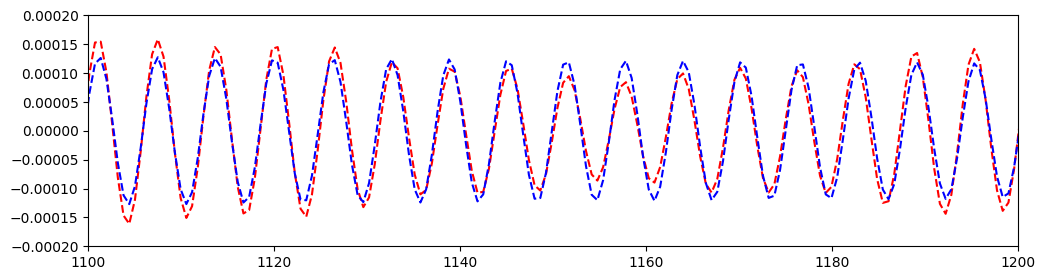

In [ ]:
plt.figure(figsize=(12,3))
#plt.plot(omega, error_filon, "r--")
#plt.plot(omega, error_levin, "b--")
#plt.plot(omega, error_gauss, "g--")
plt.plot(omega, np.imag(G_filon), "r--")
plt.plot(omega, np.imag(G_levin), "b--")
#plt.plot(omega, np.imag(G_gauss_ref), "k--")
#plt.yscale('log')
plt.ylim([-0.0002,0.0002])
plt.xlim([1100.,1200])

In [ ]:
# we suppose kx > (omega/vp)
def integrand_evan(kx, k0, z_abs, x, R_func):
    R_val = R_func(kx)
    gamma = np.sqrt(kx**2 - k0**2)
    return R_val * np.exp(1j * kx * x) * np.exp(-gamma*z_abs) / gamma

def integrand_evan_cosh(psi, k0, z_abs, x, R_func):
    kx = k0 * np.cosh(psi)
    R_val = R_func(kx)
    phase = z_abs *np.sinh(psi) - 1j * x *np.cosh(psi)
    return R_val * np.exp(-k0*phase)

In [ ]:
#freqs_ev = np.linspace(0.01, 40.0, 1024)
omega_ev = 2.0 * np.pi * freqs #+ 2.0*1j
Ng = 400
factor = 2.
start = time.time()
G_gauss_evan = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega_ev[w] / vp
    kmax = factor*k0
    G_gauss_evan[w] = gauss_legendre_quad(k0, kmax, Ng, k0, dz, dx, reflectivity_vec, integrand=integrand_evan)
end = time.time()
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", Ng)
G_gauss_evan *= -1./(2.*np.pi)
Green = green2d(omega_ev, vp, dx) 

start = time.time()
G_ch_evan = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega_ev[w] / vp
    kmax = factor*k0
    psi_max = np.arccosh(kmax/k0)
    G_ch_evan[w] = gauss_legendre_quad(0., psi_max, Ng, k0, dz, dx, reflectivity_vec, integrand=integrand_evan_cosh)
end = time.time()
print(f"quadrature elapsed: {end-start:.2f} s")
print("number of calls = ", Ng)
G_ch_evan *= -1./(2.*np.pi)

quadrature elapsed: 11.06 s
number of calls =  400
quadrature elapsed: 11.08 s
number of calls =  400


In [ ]:
'''from scipy.integrate import quad
G_scipy = np.zeros(len(omega), dtype=complex)
for w in range(len(omega)):
    k0 = omega_ev[w] / vp
    kmax = factor*k0
    result, error = quad(integrand_evan, k0, kmax, args=(k0, dz, dx, reflectivity_vec), points=[k0], limit=300)
    G_scipy[w] = result * (-1./(2.*np.pi))'''

'from scipy.integrate import quad\nG_scipy = np.zeros(len(omega), dtype=complex)\nfor w in range(len(omega)):\n    k0 = omega_ev[w] / vp\n    kmax = factor*k0\n    result, error = quad(integrand_evan, k0, kmax, args=(k0, dz, dx, reflectivity_vec), points=[k0], limit=300)\n    G_scipy[w] = result * (-1./(2.*np.pi))'

In [ ]:
error_gauss = np.abs(np.real(Green) - np.real(G_gauss_evan)) #/ np.abs(np.real(Green))
print("max err gauss", np.max(error_gauss))
error_ch = np.abs(np.real(Green) - np.real(G_ch_evan)) #/ np.abs(np.real(Green))
print("max err ch", np.max(error_ch))
#error_scipy = np.abs(np.real(Green) - np.real(G_scipy)) #/ np.abs(np.real(Green))
#print("max err scipy", np.max(error_scipy))

max err gauss 0.24966393467266473
max err ch 0.24941975554742637


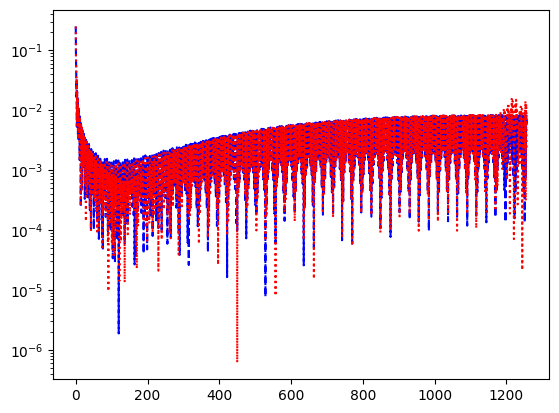

In [ ]:
plt.plot(np.real(omega_ev), error_gauss, 'b--')
plt.plot(np.real(omega_ev), error_ch, 'r:')
#plt.plot(np.real(omega_ev), error_scipy, 'g-.')
plt.yscale('log')

(0.0, 250.0)

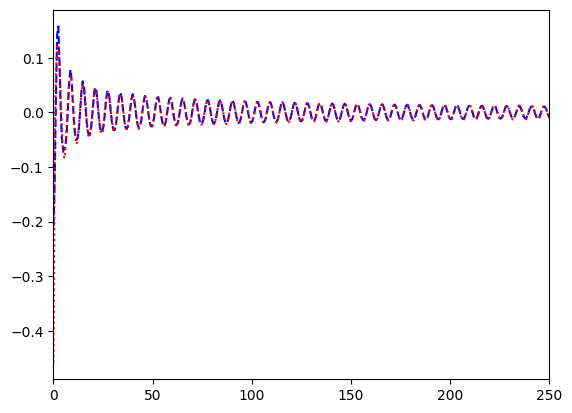

In [ ]:
plt.plot(np.real(omega_ev), np.real(G_ch_evan), 'b--')
plt.plot(np.real(omega_ev), np.real(Green), 'r:')
plt.xlim([0,250])